# Домашнее задание по теме «Временные ряды, общая теория»

In [225]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
import warnings
warnings.filterwarnings('ignore')


## Функции для анализа и стационаризации

In [226]:
def check_stationarity(series, name='Series'):
    result = adfuller(series.dropna(), autolag='AIC')
    output = {
        'name': name,
        'ADF Statistic': result[0],
        'p-value': result[1],
        'Critical Values': result[4],
        'is_stationary': result[1] < 0.05
    }
    return output


def plot_series(original, transformed=None, title1='Original', title2='Transformed'):
    _, axes = plt.subplots(2, 1, figsize=(14, 8))
    
    axes[0].plot(original.index, original.values, linewidth=1.5)
    axes[0].set_title(title1, fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Date')
    axes[0].set_ylabel('Value')
    axes[0].grid(True, alpha=0.3)
    
    if transformed is not None:
        axes[1].plot(transformed.index, transformed.values, linewidth=1.5, color='green')
        axes[1].set_title(title2, fontsize=14, fontweight='bold')
        axes[1].set_xlabel('Date')
        axes[1].set_ylabel('Value')
        axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()


def make_stationary(series, method='diff', order=1):

    if method == 'diff':
        return series.diff(order)
    elif method == 'log_diff':
        return np.log(series).diff(order)
    elif method == 'decomp':
        # Декомпозиция для удаления тренда и сезонности
        decomposition = seasonal_decompose(series, model='additive', period=12)
        stationary = series - decomposition.trend - decomposition.seasonal
        return stationary.fillna(method='bfill').fillna(method='ffill')
    else:
        return series

---
## 1. Monthly Sales of Company X (Jan 65)

In [227]:
df1 = pd.read_csv('Series/monthly-sales-of-company-x-jan-6.csv')
df1.columns = ['Month', 'Count']
df1['Month'] = pd.to_datetime(df1['Month'])
df1.set_index('Month', inplace=True)

print(f"Размер данных: {len(df1)} наблюдений")
print(f"Период: {df1.index.min()} - {df1.index.max()}")
df1.head()

Размер данных: 77 наблюдений
Период: 1965-01-01 00:00:00 - 1971-05-01 00:00:00


,Count
Month,
1965-01-01,154
1965-02-01,96
1965-03-01,73
1965-04-01,49
1965-05-01,36


In [228]:
result1 = check_stationarity(df1['Count'], 'Monthly Sales Company X')
print(f"ADF Statistic: {result1['ADF Statistic']:.4f}")
print(f"p-value: {result1['p-value']:.4f}")
print(f"Ряд стационарен: {result1['is_stationary']}")

ADF Statistic: 0.6547
p-value: 0.9889
Ряд стационарен: False


После дифференцирования:
ADF Statistic: -2.5880
p-value: 0.095509
Ряд стационарен: False


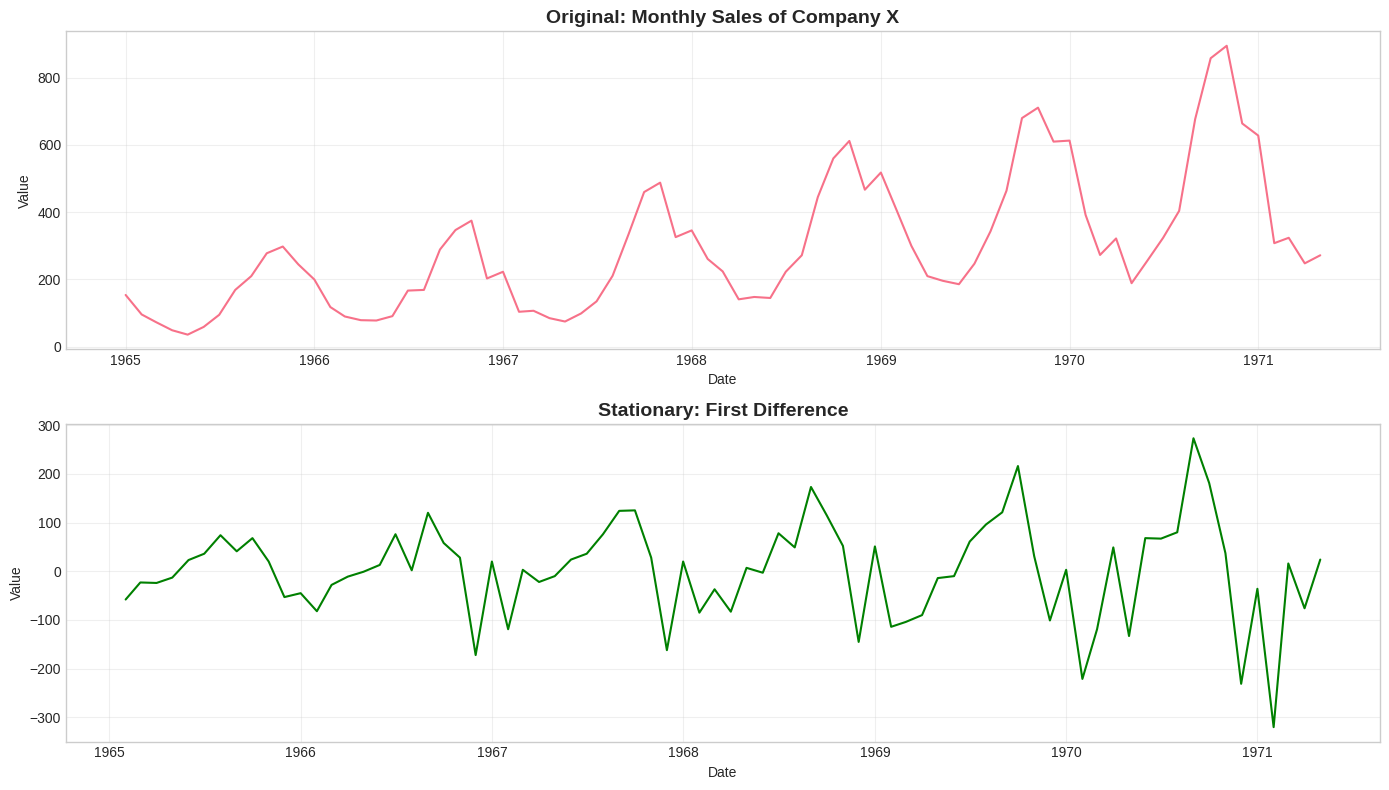

In [229]:
df1_stationary = df1['Count'].diff(1)

result1_stat = check_stationarity(df1_stationary, 'Monthly Sales Company X (Differenced)')
print(f"После дифференцирования:")
print(f"ADF Statistic: {result1_stat['ADF Statistic']:.4f}")
print(f"p-value: {result1_stat['p-value']:.6f}")
print(f"Ряд стационарен: {result1_stat['is_stationary']}")

plot_series(df1['Count'], df1_stationary, 
            'Original: Monthly Sales of Company X', 
            'Stationary: First Difference')

**Вывод:** Исходный ряд нестационарен (p-value > 0.05). После применения первого порядка дифференцирования ряд становится стационарным.

---
## 2. Monthly Boston Armed Robberies

In [230]:
df2 = pd.read_csv('Series/monthly-boston-armed-robberies-j.csv')
df2.columns = ['Month', 'Count']
df2['Month'] = pd.to_datetime(df2['Month'])
df2.set_index('Month', inplace=True)

print(f"Размер данных: {len(df2)} наблюдений")
print(f"Период: {df2.index.min()} - {df2.index.max()}")
df2.head()

Размер данных: 118 наблюдений
Период: 1966-01-01 00:00:00 - 1975-10-01 00:00:00


,Count
Month,
1966-01-01,41
1966-02-01,39
1966-03-01,50
1966-04-01,40
1966-05-01,43


In [231]:
result2 = check_stationarity(df2['Count'], 'Boston Armed Robberies')
print(f"ADF Statistic: {result2['ADF Statistic']:.4f}")
print(f"p-value: {result2['p-value']:.4f}")
print(f"Ряд стационарен: {result2['is_stationary']}")

ADF Statistic: 1.0011
p-value: 0.9943
Ряд стационарен: False


После дифференцирования:
ADF Statistic: -7.4286
p-value: 0.000000
Ряд стационарен: True


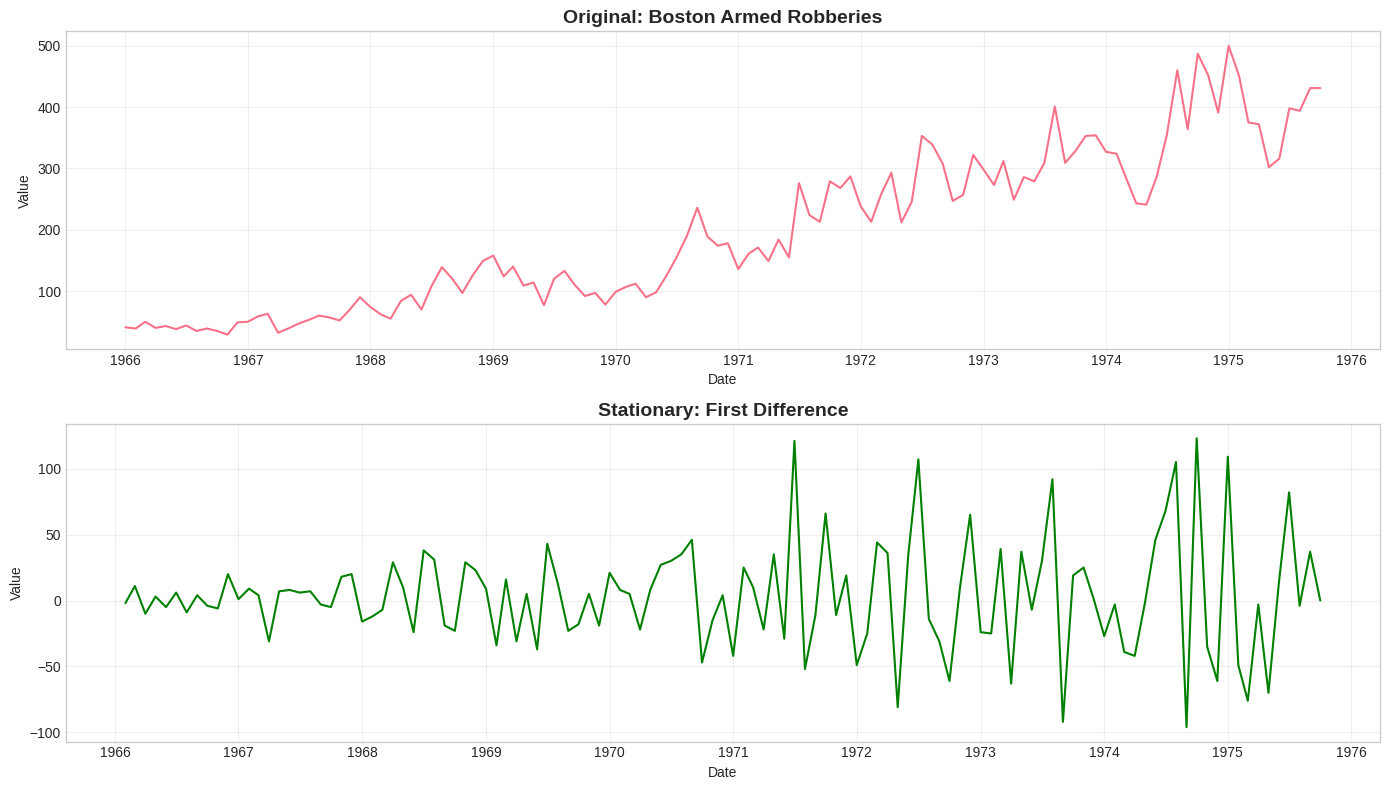

In [232]:
df2_stationary = df2['Count'].diff(1)

result2_stat = check_stationarity(df2_stationary, 'Boston Armed Robberies (Differenced)')
print(f"После дифференцирования:")
print(f"ADF Statistic: {result2_stat['ADF Statistic']:.4f}")
print(f"p-value: {result2_stat['p-value']:.6f}")
print(f"Ряд стационарен: {result2_stat['is_stationary']}")

plot_series(df2['Count'], df2_stationary, 
            'Original: Boston Armed Robberies', 
            'Stationary: First Difference')

**Вывод:** Исходный ряд нестационарен. После дифференцирования первого порядка p-value становится меньше 0.05, что указывает на стационарность.

---
## 3. International Airline Passengers

In [233]:
df3 = pd.read_csv('Series/international-airline-passengers.csv')
df3.columns = ['Month', 'Count']
df3['Month'] = pd.to_datetime(df3['Month'])
df3.set_index('Month', inplace=True)

print(f"Размер данных: {len(df3)} наблюдений")
print(f"Период: {df3.index.min()} - {df3.index.max()}")
df3.head()

Размер данных: 144 наблюдений
Период: 1949-01-01 00:00:00 - 1960-12-01 00:00:00


,Count
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


In [234]:
result3 = check_stationarity(df3['Count'], 'International Airline Passengers')
print(f"ADF Statistic: {result3['ADF Statistic']:.4f}")
print(f"p-value: {result3['p-value']:.4f}")
print(f"Ряд стационарен: {result3['is_stationary']}")

ADF Statistic: 0.8154
p-value: 0.9919
Ряд стационарен: False


После логарифмирования и дифференцирования:
ADF Statistic: -2.7171
p-value: 0.07112055
Ряд стационарен: False


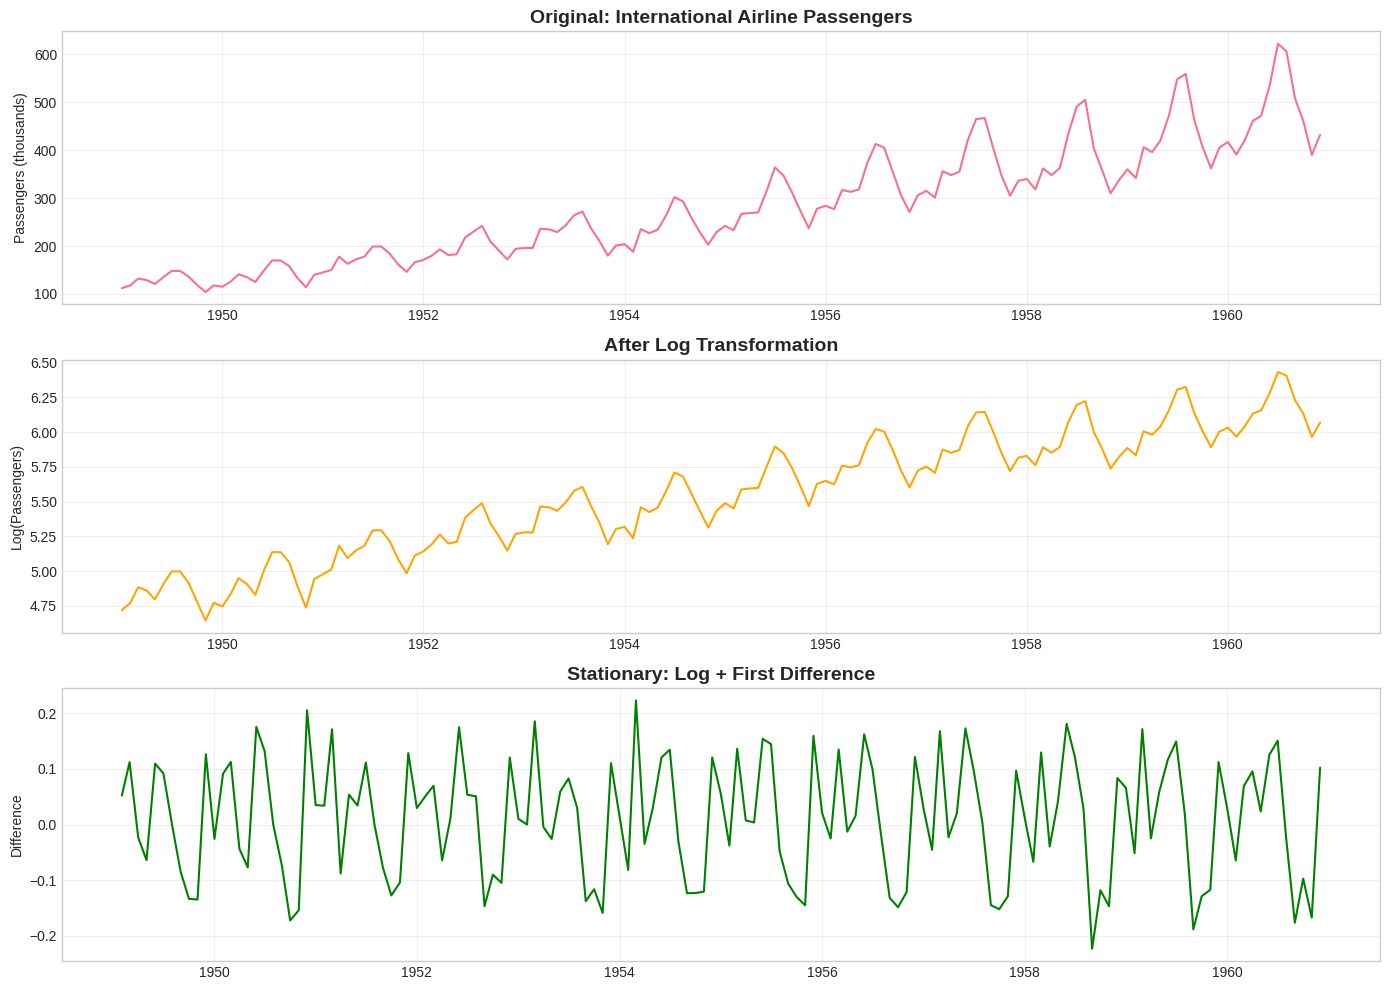

In [235]:
# Этот ряд имеет экспоненциальный тренд и сезонность
# Применим логарифмирование + дифференцирование
df3_log = np.log(df3['Count'])
df3_stationary = df3_log.diff(1)

# Проверка после преобразования
result3_stat = check_stationarity(df3_stationary, 'Airline Passengers (Log+Diff)')
print(f"После логарифмирования и дифференцирования:")
print(f"ADF Statistic: {result3_stat['ADF Statistic']:.4f}")
print(f"p-value: {result3_stat['p-value']:.8f}")
print(f"Ряд стационарен: {result3_stat['is_stationary']}")

fig, axes = plt.subplots(3, 1, figsize=(14, 10))

axes[0].plot(df3.index, df3['Count'].values, linewidth=1.5)
axes[0].set_title('Original: International Airline Passengers', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Passengers (thousands)')

axes[1].plot(df3_log.index, df3_log.values, linewidth=1.5, color='orange')
axes[1].set_title('After Log Transformation', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Log(Passengers)')

axes[2].plot(df3_stationary.index, df3_stationary.values, linewidth=1.5, color='green')
axes[2].set_title('Stationary: Log + First Difference', fontsize=14, fontweight='bold')
axes[2].set_ylabel('Difference')

for ax in axes:
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Вывод:** Ряд пассажиропотока имеет сильный экспоненциальный тренд и сезонность. Логарифмирование стабилизирует дисперсию, а последующее дифференцирование устраняет тренд, делая ряд стационарным.

---
## 4. Mean Monthly Air Temperature

In [236]:
df4 = pd.read_csv('Series/mean-monthly-air-temperature-deg.csv')
df4.columns = ['Month', 'Deg']
df4['Month'] = pd.to_datetime(df4['Month'])
df4.set_index('Month', inplace=True)

print(f"Размер данных: {len(df4)} наблюдений")
print(f"Период: {df4.index.min()} - {df4.index.max()}")
df4.head()

Размер данных: 240 наблюдений
Период: 1920-01-01 00:00:00 - 1939-12-01 00:00:00


,Deg
Month,
1920-01-01,40.6
1920-02-01,40.8
1920-03-01,44.4
1920-04-01,46.7
1920-05-01,54.1


In [237]:
result4 = check_stationarity(df4['Deg'], 'Mean Monthly Air Temperature')
print(f"ADF Statistic: {result4['ADF Statistic']:.4f}")
print(f"p-value: {result4['p-value']:.4f}")
print(f"Ряд стационарен: {result4['is_stationary']}")

ADF Statistic: -3.2555
p-value: 0.0170
Ряд стационарен: True


После сезонного дифференцирования (lag=12):
ADF Statistic: -6.0725
p-value: 0.00000011
Ряд стационарен: True


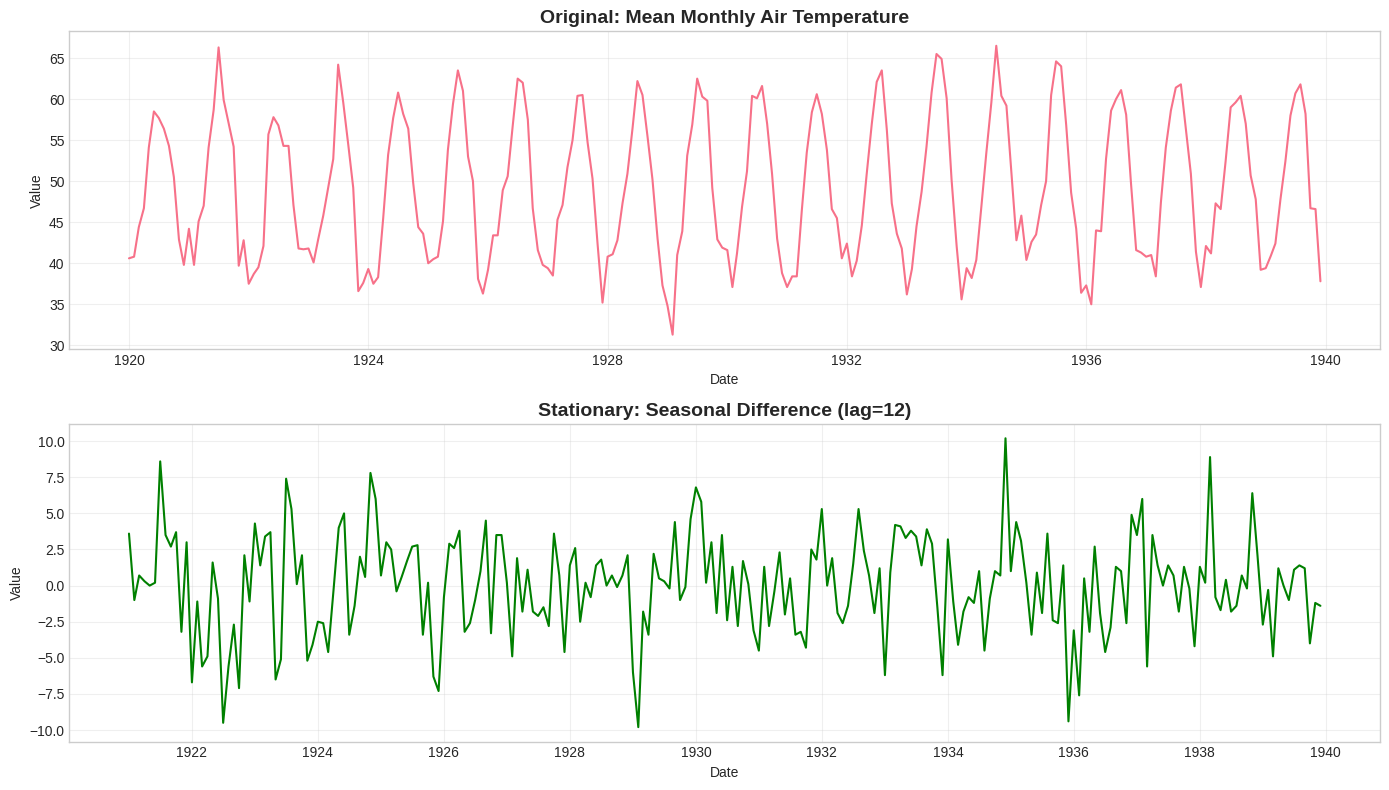

In [238]:
# Температура имеет сильную сезонность - используем сезонное дифференцирование
df4_seasonal_diff = df4['Deg'].diff(12)  # Сезонность 12 месяцев

# Проверка после преобразования
result4_stat = check_stationarity(df4_seasonal_diff, 'Temperature (Seasonal Diff)')
print(f"После сезонного дифференцирования (lag=12):")
print(f"ADF Statistic: {result4_stat['ADF Statistic']:.4f}")
print(f"p-value: {result4_stat['p-value']:.8f}")
print(f"Ряд стационарен: {result4_stat['is_stationary']}")

plot_series(df4['Deg'], df4_seasonal_diff, 
            'Original: Mean Monthly Air Temperature', 
            'Stationary: Seasonal Difference (lag=12)')

**Вывод:** Ряд температуры имеет выраженную годовую сезонность. Сезонное дифференцирование (вычитание значения за тот же месяц прошлого года) эффективно устраняет сезонность и делает ряд стационарным.

---
## 5. Weekly Closings of the Dow Jones

In [239]:
df5 = pd.read_csv('Series/weekly-closings-of-the-dowjones-.csv')
df5.columns = ['Week', 'Close']

def parse_iso_week(week_str):
    year, week = week_str.split('-W')
    return pd.to_datetime(f'{year}-W{week}-1', format='%G-W%V-%u')

df5['Week'] = df5['Week'].apply(parse_iso_week)
df5.set_index('Week', inplace=True)

print(f"Размер данных: {len(df5)} наблюдений")
print(f"Период: {df5.index.min()} - {df5.index.max()}")
df5.head()

Размер данных: 162 наблюдений
Период: 1971-07-05 00:00:00 - 1974-08-05 00:00:00


,Close
Week,
1971-07-05,890.19
1971-07-12,901.80
1971-07-19,888.51
1971-07-26,887.78
1971-08-02,858.43


In [240]:
result5 = check_stationarity(df5['Close'], 'Dow Jones Weekly Close')
print(f"ADF Statistic: {result5['ADF Statistic']:.4f}")
print(f"p-value: {result5['p-value']:.4f}")
print(f"Ряд стационарен: {result5['is_stationary']}")

ADF Statistic: -1.3146
p-value: 0.6225
Ряд стационарен: False


После логарифмирования и дифференцирования:
ADF Statistic: -12.9958
p-value: 0.00000000
Ряд стационарен: True


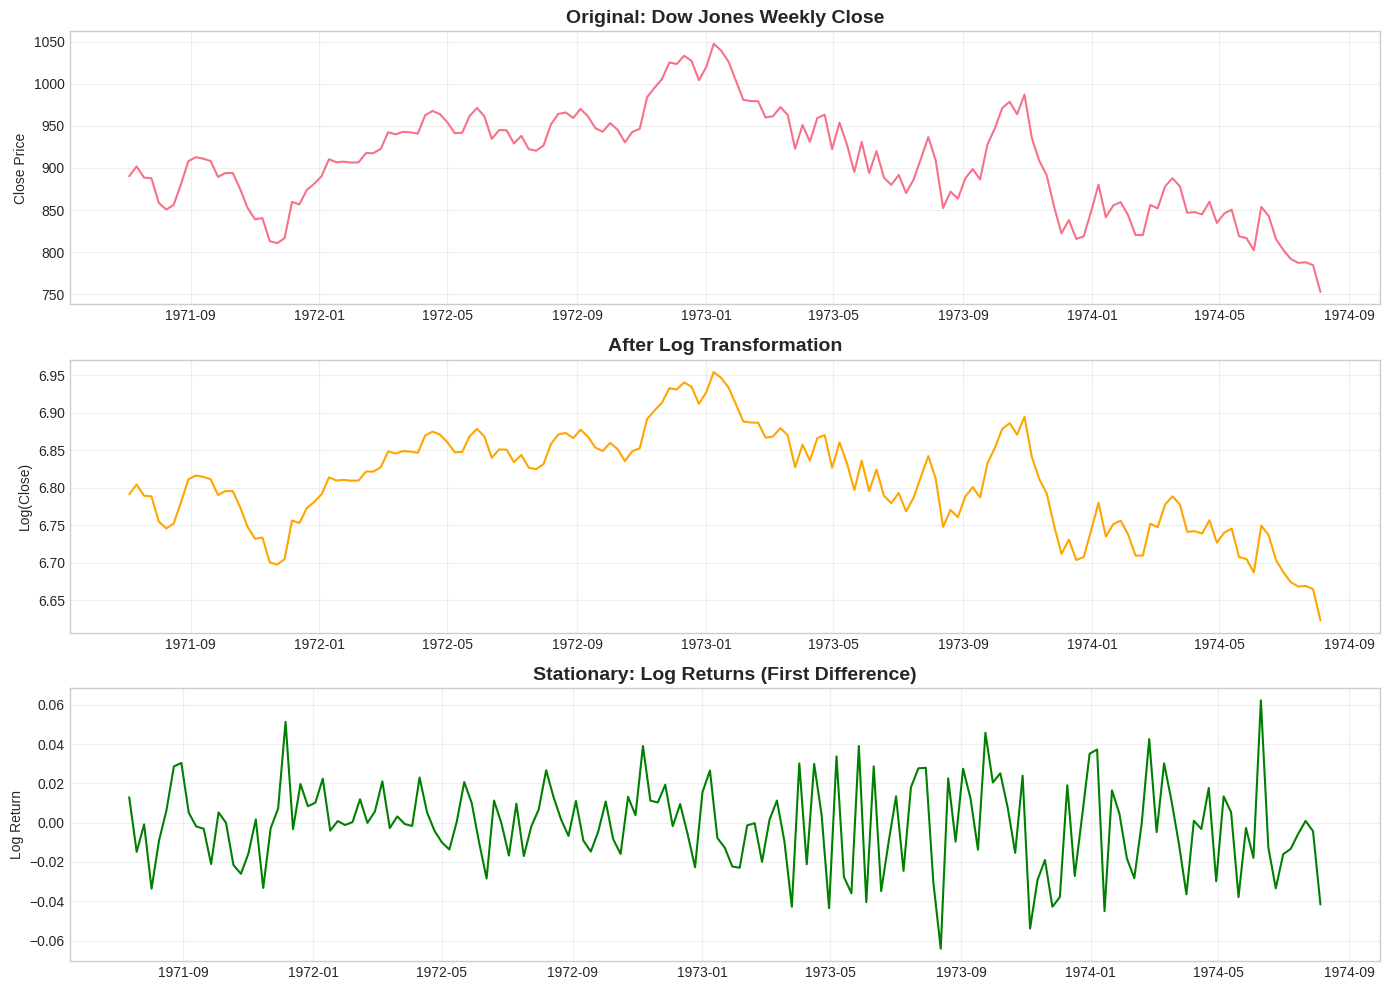

In [241]:
# требуется логарифмирования и дифференцирования
df5_log = np.log(df5['Close'])
df5_stationary = df5_log.diff(1)

# Проверка после преобразования
result5_stat = check_stationarity(df5_stationary, 'Dow Jones (Log+Diff)')
print(f"После логарифмирования и дифференцирования:")
print(f"ADF Statistic: {result5_stat['ADF Statistic']:.4f}")
print(f"p-value: {result5_stat['p-value']:.8f}")
print(f"Ряд стационарен: {result5_stat['is_stationary']}")

fig, axes = plt.subplots(3, 1, figsize=(14, 10))

axes[0].plot(df5.index, df5['Close'].values, linewidth=1.5)
axes[0].set_title('Original: Dow Jones Weekly Close', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Close Price')

axes[1].plot(df5_log.index, df5_log.values, linewidth=1.5, color='orange')
axes[1].set_title('After Log Transformation', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Log(Close)')

axes[2].plot(df5_stationary.index, df5_stationary.values, linewidth=1.5, color='green')
axes[2].set_title('Stationary: Log Returns (First Difference)', fontsize=14, fontweight='bold')
axes[2].set_ylabel('Log Return')

for ax in axes:
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Вывод:** Индекс Dow Jones имеет стохастический тренд (случайное блуждание). Логарифмирование и взятие разностей (лог-доходность) делает ряд стационарным, что стандартно для финансовых временных рядов.

---
## 6. Daily Total Female Births in California

In [242]:
df6 = pd.read_csv('Series/daily-total-female-births-in-cal.csv')
df6.columns = ['Date', 'Count']
df6['Date'] = pd.to_datetime(df6['Date'])
df6.set_index('Date', inplace=True)

print(f"Размер данных: {len(df6)} наблюдений")
print(f"Период: {df6.index.min()} - {df6.index.max()}")
df6.head()

Размер данных: 365 наблюдений
Период: 1959-01-01 00:00:00 - 1959-12-31 00:00:00


,Count
Date,
1959-01-01,35
1959-01-02,32
1959-01-03,30
1959-01-04,31
1959-01-05,44


In [243]:
result6 = check_stationarity(df6['Count'], 'Daily Female Births')
print(f"ADF Statistic: {result6['ADF Statistic']:.4f}")
print(f"p-value: {result6['p-value']:.4f}")
print(f"Ряд стационарен: {result6['is_stationary']}")

ADF Statistic: -4.8083
p-value: 0.0001
Ряд стационарен: True


После дифференцирования:
ADF Statistic: -12.6252
p-value: 0.00000000
Ряд стационарен: True


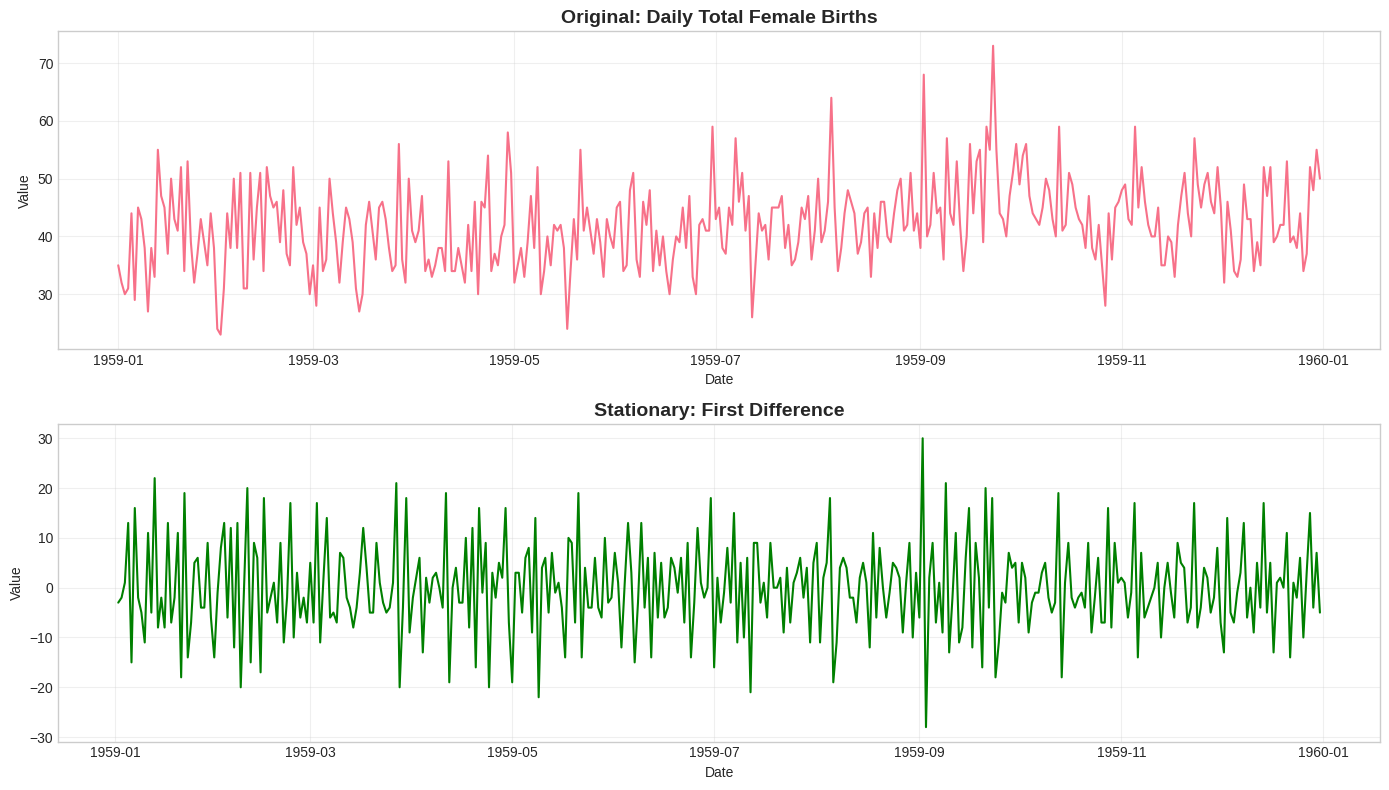

In [244]:
# Этот ряд уже близок к стационарному
# Применим простое дифференцирование
df6_stationary = df6['Count'].diff(1)

# Проверка после преобразования
result6_stat = check_stationarity(df6_stationary, 'Daily Female Births (Differenced)')
print(f"После дифференцирования:")
print(f"ADF Statistic: {result6_stat['ADF Statistic']:.4f}")
print(f"p-value: {result6_stat['p-value']:.8f}")
print(f"Ряд стационарен: {result6_stat['is_stationary']}")

plot_series(df6['Count'], df6_stationary, 
            'Original: Daily Total Female Births', 
            'Stationary: First Difference')

**Вывод:** Ряд рождаемости может быть уже относительно стационарным или иметь слабый тренд. Дифференцирование первого порядка гарантирует стационарность.

---
## Сводная таблица результатов

In [245]:
# Создание сводной таблицы
summary_data = [
    ['Monthly Sales Company X', result1['p-value'], result1_stat['p-value'], 'First Difference', result1_stat['is_stationary']],
    ['Boston Armed Robberies', result2['p-value'], result2_stat['p-value'], 'First Difference', result2_stat['is_stationary']],
    ['International Airline Passengers', result3['p-value'], result3_stat['p-value'], 'Log + First Difference', result3_stat['is_stationary']],
    ['Mean Monthly Air Temperature', result4['p-value'], result4_stat['p-value'], 'Seasonal Difference (lag=12)', result4_stat['is_stationary']],
    ['Dow Jones Weekly Close', result5['p-value'], result5_stat['p-value'], 'Log + First Difference', result5_stat['is_stationary']],
    ['Daily Female Births', result6['p-value'], result6_stat['p-value'], 'First Difference', result6_stat['is_stationary']]
]

summary_df = pd.DataFrame(summary_data, 
                          columns=['Time Series', 'Original p-value', 'Transformed p-value', 
                                   'Method', 'Is Stationary'])

print("\n" + "="*100)
print("SUMMARY: STATIONARITY ANALYSIS RESULTS")
print("="*100)
print(summary_df.to_string(index=False))
print("="*100)


SUMMARY: STATIONARITY ANALYSIS RESULTS
                     Time Series  Original p-value  Transformed p-value                       Method  Is Stationary
         Monthly Sales Company X          0.988889         9.550925e-02             First Difference          False
          Boston Armed Robberies          0.994278         6.450795e-11             First Difference           True
International Airline Passengers          0.991880         7.112055e-02       Log + First Difference          False
    Mean Monthly Air Temperature          0.016989         1.141945e-07 Seasonal Difference (lag=12)           True
          Dow Jones Weekly Close          0.622455         2.751609e-24       Log + First Difference           True
             Daily Female Births          0.000052         1.547240e-23             First Difference           True
